In [1]:
# Library for feature engineering and EDA
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas_profiling
from datetime import datetime
import random
# Library for Statistics.
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
from scipy.stats import skew
from scipy.stats import kurtosis
# Library for sampling 
from imblearn.over_sampling import SMOTE
# Library for machine learning
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
import shap
%matplotlib inline


C:\Users\TaeyoonKim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numba\core\decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)
C:\Users\TaeyoonKim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\visions\backends\shared\nan_handling.py:50: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-

C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_39012\4260162244.py:6: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  import pandas_profiling


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/petfinder-mini.csv')
df.head(10)

,Type,Age,Breed1,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,Sterilized,Health,Fee,Description,PhotoAmt,AdoptionSpeed
0,Cat,3,Tabby,Male,Black,White,Small,Short,No,No,Healthy,100,Nibble is a 3+ month old ball of cuteness. He ...,1,2
1,Cat,1,Domestic Medium Hair,Male,Black,Brown,Medium,Medium,Not Sure,Not Sure,Healthy,0,I just found it alone yesterday near my apartm...,2,0
2,Dog,1,Mixed Breed,Male,Brown,White,Medium,Medium,Yes,No,Healthy,0,Their pregnant mother was dumped by her irresp...,7,3
3,Dog,4,Mixed Breed,Female,Black,Brown,Medium,Short,Yes,No,Healthy,150,"Good guard dog, very alert, active, obedience ...",8,2
4,Dog,1,Mixed Breed,Male,Black,No Color,Medium,Short,No,No,Healthy,0,This handsome yet cute boy is up for adoption....,3,2
5,Cat,3,Domestic Short Hair,Female,Cream,Gray,Medium,Short,No,No,Healthy,0,This is a stray kitten that came to my house. ...,2,2
6,Cat,12,Domestic Long Hair,Male,Black,No Color,Medium,Long,No,Not Sure,Healthy,300,anyone within the area of ipoh or taiping who ...,3,1
7,Cat,2,Domestic Medium Hair,Female,Gray,No Color,Medium,Medium,No,No,Healthy,0,"healthy and active, feisty kitten found in nei...",6,1
8,Cat,12,Domestic Medium Hair,Female,Black,White,Medium,Medium,Not Sure,Not Sure,Healthy,0,"Very manja and gentle stray cat found, we woul...",2,4
9,Dog,2,Mixed Breed,Male,Black,Brown,Medium,Short,No,No,Healthy,0,"For serious adopter, please do sms or call for...",7,1


In [3]:
df.info() 
# Very few missing values.
# All types are good.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11537 entries, 0 to 11536
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Type           11537 non-null  object
 1   Age            11537 non-null  int64 
 2   Breed1         11537 non-null  object
 3   Gender         11537 non-null  object
 4   Color1         11537 non-null  object
 5   Color2         11537 non-null  object
 6   MaturitySize   11537 non-null  object
 7   FurLength      11537 non-null  object
 8   Vaccinated     11537 non-null  object
 9   Sterilized     11537 non-null  object
 10  Health         11537 non-null  object
 11  Fee            11537 non-null  int64 
 12  Description    11528 non-null  object
 13  PhotoAmt       11537 non-null  int64 
 14  AdoptionSpeed  11537 non-null  int64 
dtypes: int64(4), object(11)
memory usage: 1.3+ MB


In [4]:
for column_name in list(df.columns):
    print(column_name, df[column_name].dtype, df[column_name].unique())
# Some ages are outliers
# Some breed1 might be duplicated.
# What is color1 and color 2?
# Description can be used for sentimental analysis/ clustering
# Adoption speed is target from 0-4. 0 is the fastest, 4 is the slowest?

Type object ['Cat' 'Dog']
Age int64 [  3   1   4  12   2  78   6   8  10  36  14   5  72  60  24   9  48  62
  47  19 120   7  17  22  16  13  11  37  18  55  20  28  74  53  25  84
  76  30 132   0  96  46  15  50  56  54  92  29  27  49  44 144  21  31
  41  51  65  34 135  39  52  23  42 108  81  26  38  69 212  33  75  95
  80  63  61 255  89  32  91  35 117  73 122 123  64  87 112 156  66  67
  77 180  82  86  40  57 168 102  45 147  68  85  88 238 100]
Breed1 object ['Tabby' 'Domestic Medium Hair' 'Mixed Breed' 'Domestic Short Hair'
 'Domestic Long Hair' 'Terrier' 'Persian' 'Rottweiler'
 'Jack Russell Terrier' 'Shih Tzu' 'Labrador Retriever' 'Silky Terrier'
 'Bombay' 'Husky' 'Schnauzer' 'Golden Retriever' 'Siberian Husky' 'Collie'
 'German Shepherd Dog' 'Siamese' 'Calico' 'American Staffordshire Terrier'
 'Turkish Van' 'Doberman Pinscher' 'Oriental Short Hair' 'Beagle'
 'Ragdoll' 'Cocker Spaniel' 'Poodle' 'Black Labrador Retriever' 'Bengal'
 'Shar Pei' 'Spitz' 'Birman' 'Belgian S

In [5]:
df.isna().sum().sort_values(ascending=False)
df = df.dropna(subset='Description') # Drop 9 missing description duplicates. or just adding values. replace nan to unknown.

In [6]:
df.isna().sum().sort_values(ascending=False)

Type             0
Age              0
Breed1           0
Gender           0
Color1           0
Color2           0
MaturitySize     0
FurLength        0
Vaccinated       0
Sterilized       0
Health           0
Fee              0
Description      0
PhotoAmt         0
AdoptionSpeed    0
dtype: int64

In [7]:
list_categorical_columns = list(df.select_dtypes(include=['object']).columns)
list_numeric_columns = list(df.select_dtypes(include=['int64']).columns)
target_column ='AdoptionSpeed'
print(len(df.columns))
print(len(list_categorical_columns))
print(len(list_numeric_columns))

15
11
4


In [9]:
df[target_column].value_counts()

AdoptionSpeed
2    3149
4    3077
3    2543
1    2430
0     329
Name: count, dtype: int64

<Figure size 3000x3000 with 0 Axes>

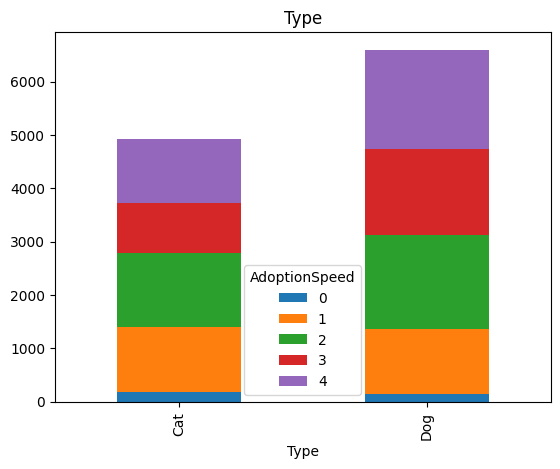

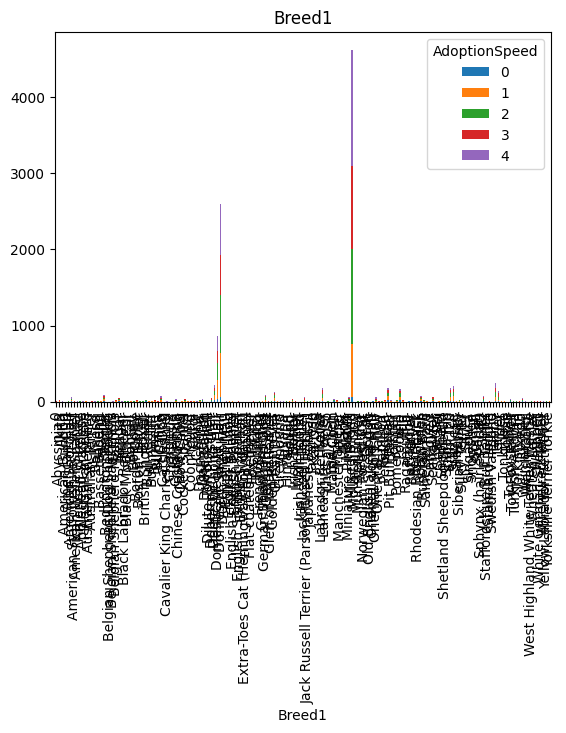

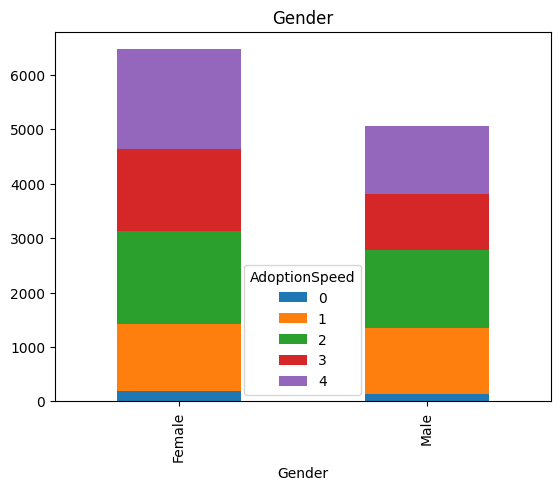

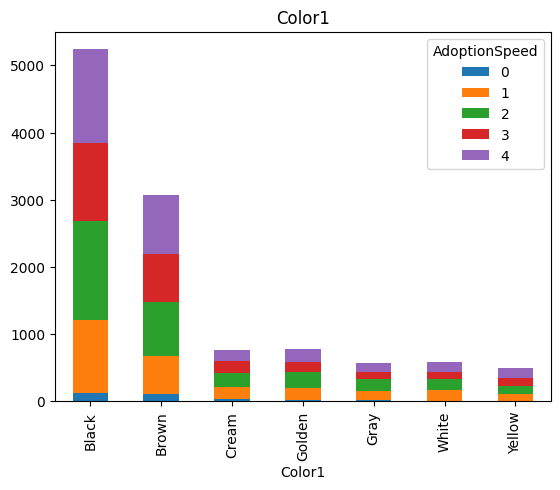

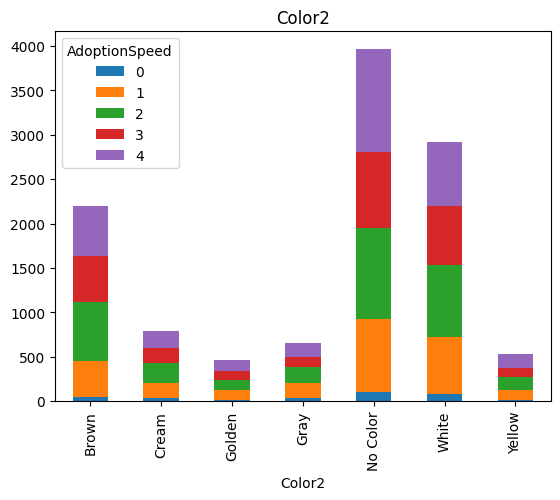

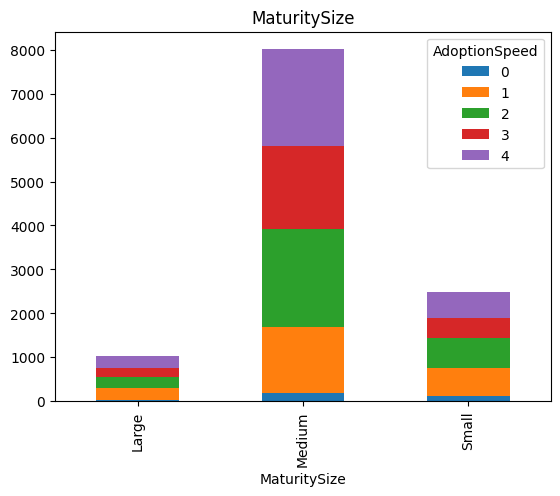

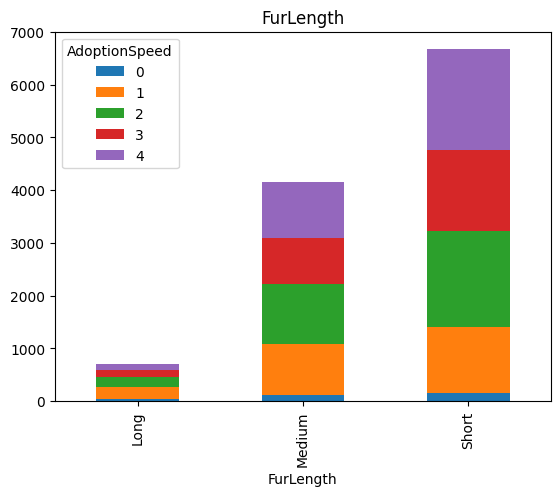

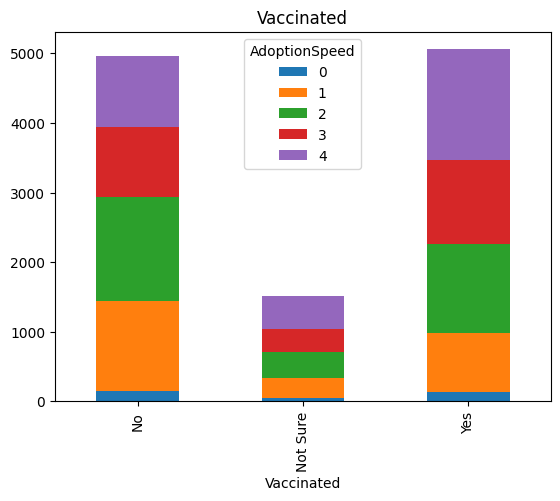

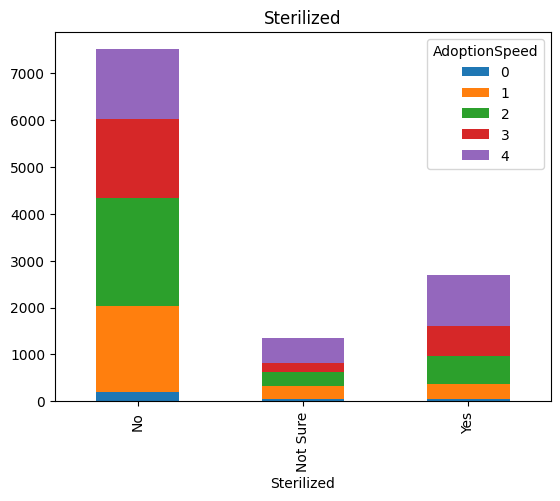

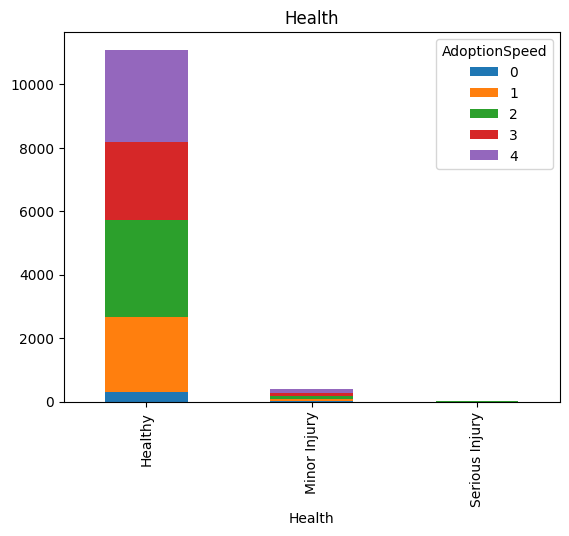

Glyph 26106 (\N{CJK UNIFIED IDEOGRAPH-65FA}) missing from font(s) DejaVu Sans.
Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) DejaVu Sans.
Glyph 26159 (\N{CJK UNIFIED IDEOGRAPH-662F}) missing from font(s) DejaVu Sans.
Glyph 20004 (\N{CJK UNIFIED IDEOGRAPH-4E24}) missing from font(s) DejaVu Sans.
Glyph 27506 (\N{CJK UNIFIED IDEOGRAPH-6B72}) missing from font(s) DejaVu Sans.
Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
Glyph 29399 (\N{CJK UNIFIED IDEOGRAPH-72D7}) missing from font(s) DejaVu Sans.
Glyph 37027 (\N{CJK UNIFIED IDEOGRAPH-90A3}) missing from font(s) DejaVu Sans.
Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
Glyph 35211 (\N{CJK UNIFIED IDEOGRAPH-898B}) missing from font(s) DejaVu Sans.
Glyph 22905 (\N{CJK UNIFIED IDEOGRAPH-5979}) missing from font(s) DejaVu Sans.
Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing

KeyboardInterrupt: 

In [11]:
plt.figure(figsize=(30,30))
x = 1
for column_name in list_categorical_columns:
       pd.crosstab(df[column_name], df[target_column]).plot(kind="bar", stacked=True)
       plt.title(column_name)
       plt.show()


In [13]:
list_meaningful_column_by_chi = []
for column_name in list_categorical_columns:
    statistic, pvalue, _, _ = chi2_contingency(pd.crosstab(df[target_column], df[column_name]))
    if pvalue <= 0.05:
       list_meaningful_column_by_chi.append(column_name)
       print(column_name, statistic, pvalue)
print("all categorical columns : ", len(list_categorical_columns))
print("selected categorical columns by chi : ", len(list_meaningful_column_by_chi), list_meaningful_column_by_chi)


Type 132.74190954459348 1.0090978617147374e-27
Breed1 1371.0615082666714 4.798393987210055e-52
Gender 59.22142521620607 4.227701821270044e-12
Color1 77.87669625937033 1.3209996283453042e-07
Color2 93.3235681963631 4.033902606109309e-10
MaturitySize 142.0469166284267 8.900779566672797e-27
FurLength 157.52128707587661 5.2736132874601e-30
Vaccinated 270.6379470734843 7.199537809755322e-54
Sterilized 688.2046777990099 2.477173494412187e-143
Health 37.97707681387934 7.602056920242433e-06
Description 44421.04224464688 1.0097175700772498e-08
all categorical columns :  11
selected categorical columns by chi :  11 ['Type', 'Breed1', 'Gender', 'Color1', 'Color2', 'MaturitySize', 'FurLength', 'Vaccinated', 'Sterilized', 'Health', 'Description']


In [14]:
list_kruskall_test = []
for column_name in list_numeric_columns:
       list_by_value = []
       for value in df[target_column].dropna().unique():
              df_tmp = df[df[target_column] == value][column_name].dropna()      
              list_by_value.append(np.array(df_tmp))
              statistic, pvalue = kruskal(*list_by_value)
              if pvalue <= 0.05:
                   list_kruskall_test.append(column_name)
              print(column_name, ", ",statistic,", ", pvalue)
print("all categorical columns : ", len(list_numeric_columns))
print("selected columns by kruskal : ", len(list_kruskall_test), list_kruskall_test)


ValueError: Need at least two groups in stats.kruskal()